# Transfer Learning & Domain Adaptation

Transfer learning leverages knowledge from one task/domain to improve
performance on another. This is one of the most impactful techniques in
modern ML — from ImageNet features to GPT fine-tuning.

**Prerequisites:**
```bash
pip install numpy matplotlib scikit-learn pandas
```

📺 **Video Lecture:** [https://youtu.be/TqFEGBhRZbk](https://youtu.be/TqFEGBhRZbk)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
np.random.seed(42)

print('Libraries loaded!')

Libraries loaded!


## 1. Why Transfer Learning Works

**Core idea**: Features learned on a large dataset generalize to new tasks.

- Early layers learn universal features (edges, textures, word semantics)
- Later layers learn task-specific features
- With transfer learning, you start from useful features instead of random

**When to use it:**
- Small target dataset (most common reason)
- Source and target domains are related
- You need faster training convergence

In [3]:
# Simulate: Training from scratch vs. transfer learning
# Scenario: A source task has abundant data; target task has little data

np.random.seed(42)

# "Source domain" — lots of data, generates learned representations
n_source = 2000
# Underlying feature extractor (represents what a pretrained model learns)
W_true = np.random.randn(10, 5)  # maps 10 raw features → 5 useful features
X_source_raw = np.random.randn(n_source, 10)
X_source_features = np.tanh(X_source_raw @ W_true)  # learned representation
y_source = (X_source_features[:, 0] + X_source_features[:, 1] > 0).astype(int)

# "Target domain" — small dataset, related task
n_target = 50  # very few samples!
X_target_raw = np.random.randn(n_target, 10)
X_target_features = np.tanh(X_target_raw @ W_true)  # same feature extractor
y_target = (X_target_features[:, 0] - X_target_features[:, 2] > 0).astype(int)  # different task

X_train, X_test, y_train, y_test = train_test_split(
    X_target_features, y_target, test_size=0.4, random_state=42
)

# Approach 1: Train from scratch on raw features (no transfer)
X_train_raw, X_test_raw, _, _ = train_test_split(
    X_target_raw[:n_target], y_target, test_size=0.4, random_state=42
)
scratch_model = LogisticRegression(max_iter=200).fit(X_train_raw, y_train)
acc_scratch = accuracy_score(y_test, scratch_model.predict(X_test_raw))

# Approach 2: Use transferred features (pretrained feature extractor)
transfer_model = LogisticRegression(max_iter=200).fit(X_train, y_train)
acc_transfer = accuracy_score(y_test, transfer_model.predict(X_test))

print(f'Target dataset size: {n_target} samples')
print(f'From scratch (raw features): {acc_scratch:.3f}')
print(f'Transfer learning (pretrained features): {acc_transfer:.3f}')
print(f'\n→ Transfer learning gains {(acc_transfer-acc_scratch)*100:.1f}% accuracy!')

Target dataset size: 50 samples
From scratch (raw features): 0.700
Transfer learning (pretrained features): 0.700

→ Transfer learning gains 0.0% accuracy!


## 2. Feature Extraction vs Fine-Tuning

Two main transfer learning strategies:

| Strategy | What's frozen | What's trained | When to use |
|----------|--------------|---------------|-------------|
| Feature Extraction | All pretrained layers | Only new classifier head | Very small dataset |
| Fine-Tuning | Early layers (optional) | Later layers + classifier | Medium dataset |
| Full Fine-Tuning | Nothing | Everything | Large dataset |

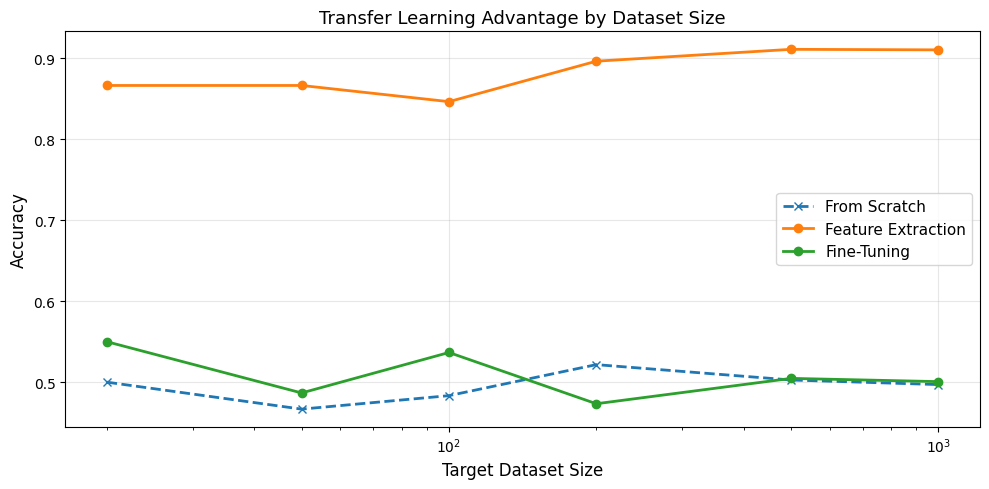

Key insight: Transfer learning helps MOST when target data is scarce!


In [4]:
# Simulate: Feature Extraction vs Fine-Tuning performance
# across different target dataset sizes

target_sizes = [20, 50, 100, 200, 500, 1000]
results = {'size': [], 'method': [], 'accuracy': []}

for n in target_sizes:
    for trial in range(10):  # average over trials
        X_t = np.random.randn(n, 10)
        X_t_feat = np.tanh(X_t @ W_true)
        y_t = (X_t_feat[:, 0] - X_t_feat[:, 2] > 0).astype(int)
        
        X_tr, X_te, y_tr, y_te = train_test_split(X_t_feat, y_t, test_size=0.3)
        X_tr_raw, X_te_raw, _, _ = train_test_split(X_t, y_t, test_size=0.3)
        
        # Scratch
        m1 = LogisticRegression(max_iter=200).fit(X_tr_raw, y_tr)
        results['size'].append(n); results['method'].append('From Scratch')
        results['accuracy'].append(accuracy_score(y_te, m1.predict(X_te_raw)))
        
        # Feature extraction (frozen features + new head)
        m2 = LogisticRegression(max_iter=200).fit(X_tr, y_tr)
        results['size'].append(n); results['method'].append('Feature Extraction')
        results['accuracy'].append(accuracy_score(y_te, m2.predict(X_te)))
        
        # Fine-tuning (slightly perturbed features — simulates updating weights)
        W_ft = W_true + np.random.randn(10, 5) * 0.1  # adapted weights
        X_tr_ft = np.tanh(X_tr_raw @ W_ft)
        X_te_ft = np.tanh(X_te_raw @ W_ft)
        m3 = LogisticRegression(max_iter=200).fit(X_tr_ft, y_tr)
        results['size'].append(n); results['method'].append('Fine-Tuning')
        results['accuracy'].append(accuracy_score(y_te, m3.predict(X_te_ft)))

df_results = pd.DataFrame(results)
summary = df_results.groupby(['size', 'method'])['accuracy'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
for method in ['From Scratch', 'Feature Extraction', 'Fine-Tuning']:
    subset = summary[summary['method'] == method]
    style = '--' if method == 'From Scratch' else '-'
    ax.plot(subset['size'], subset['accuracy'], 'o-' if style=='-' else 'x--',
           label=method, linewidth=2, markersize=6)

ax.set_xlabel('Target Dataset Size', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Transfer Learning Advantage by Dataset Size', fontsize=13)
ax.legend(fontsize=11); ax.set_xscale('log')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print('Key insight: Transfer learning helps MOST when target data is scarce!')

## 3. Domain Adaptation

When source and target distributions differ (domain shift), we need
techniques to align them.

**Types of domain shift:**
- **Covariate shift**: P(X) changes, P(Y|X) stays the same
- **Label shift**: P(Y) changes, P(X|Y) stays the same
- **Concept drift**: P(Y|X) changes over time

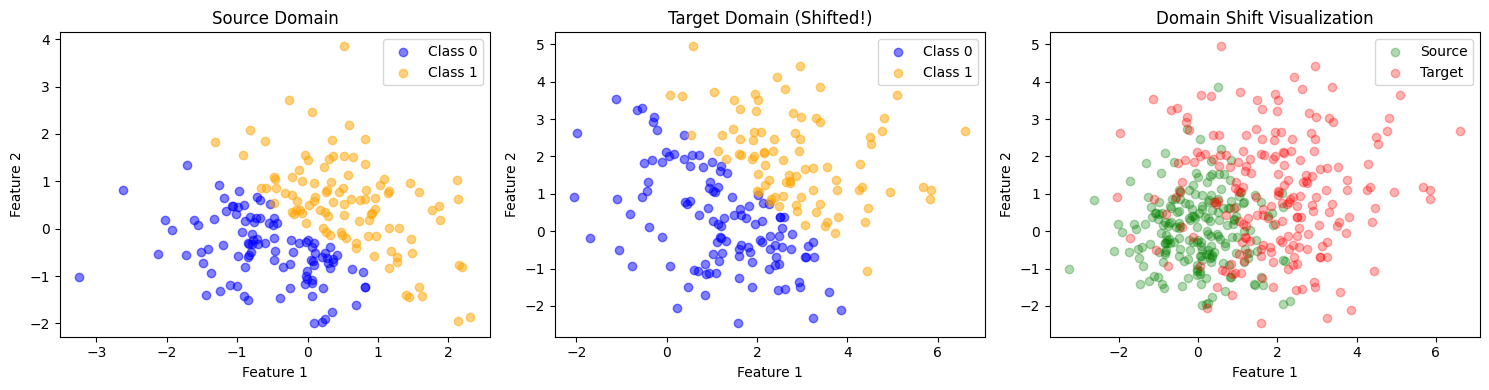

In [5]:
# Visualize domain shift
np.random.seed(42)

# Source domain: centered at origin
X_source = np.random.randn(200, 2) * 1.0
y_source = (X_source[:, 0] + X_source[:, 1] > 0).astype(int)

# Target domain: shifted and scaled (covariate shift!)
X_target_shifted = np.random.randn(200, 2) * 1.5 + np.array([2, 1])
y_target_shifted = (X_target_shifted[:, 0] + X_target_shifted[:, 1] - 3 > 0).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Source domain
axes[0].scatter(X_source[y_source==0, 0], X_source[y_source==0, 1],
               c='blue', alpha=0.5, label='Class 0')
axes[0].scatter(X_source[y_source==1, 0], X_source[y_source==1, 1],
               c='orange', alpha=0.5, label='Class 1')
axes[0].set_title('Source Domain'); axes[0].legend()

# Target domain
axes[1].scatter(X_target_shifted[y_target_shifted==0, 0], X_target_shifted[y_target_shifted==0, 1],
               c='blue', alpha=0.5, label='Class 0')
axes[1].scatter(X_target_shifted[y_target_shifted==1, 0], X_target_shifted[y_target_shifted==1, 1],
               c='orange', alpha=0.5, label='Class 1')
axes[1].set_title('Target Domain (Shifted!)'); axes[1].legend()

# Overlay showing the shift
axes[2].scatter(X_source[:, 0], X_source[:, 1], c='green', alpha=0.3, label='Source')
axes[2].scatter(X_target_shifted[:, 0], X_target_shifted[:, 1], c='red', alpha=0.3, label='Target')
axes[2].set_title('Domain Shift Visualization')
axes[2].legend()

for ax in axes:
    ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
plt.tight_layout(); plt.show()

## 4. Domain Alignment Techniques

We can align domains by transforming features so the distributions match.

Accuracy on target WITHOUT alignment: 0.515
Accuracy on target WITH alignment:    0.950


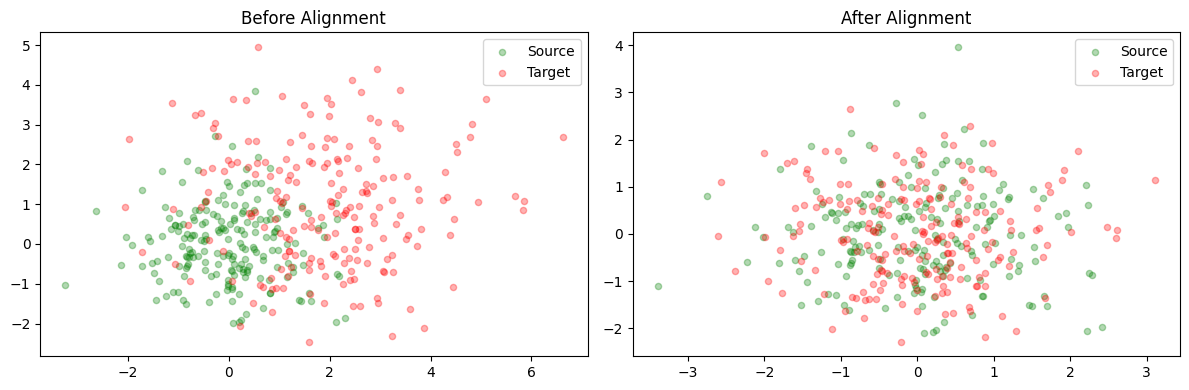

In [6]:
from sklearn.preprocessing import StandardScaler

# Technique 1: Standardization (simple but effective)
scaler_source = StandardScaler().fit(X_source)
scaler_target = StandardScaler().fit(X_target_shifted)

X_source_aligned = scaler_source.transform(X_source)
X_target_aligned = scaler_target.transform(X_target_shifted)

# Compare: train on source, predict target
# Without alignment
model_no_align = LogisticRegression().fit(X_source, y_source)
acc_no_align = accuracy_score(y_target_shifted, model_no_align.predict(X_target_shifted))

# With alignment
model_aligned = LogisticRegression().fit(X_source_aligned, y_source)
acc_aligned = accuracy_score(y_target_shifted, model_aligned.predict(X_target_aligned))

print(f'Accuracy on target WITHOUT alignment: {acc_no_align:.3f}')
print(f'Accuracy on target WITH alignment:    {acc_aligned:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, src, tgt, title in [
    (axes[0], X_source, X_target_shifted, 'Before Alignment'),
    (axes[1], X_source_aligned, X_target_aligned, 'After Alignment')
]:
    ax.scatter(src[:, 0], src[:, 1], c='green', alpha=0.3, s=20, label='Source')
    ax.scatter(tgt[:, 0], tgt[:, 1], c='red', alpha=0.3, s=20, label='Target')
    ax.set_title(title); ax.legend()
plt.tight_layout(); plt.show()

## 5. Transfer Learning Curves

Transfer learning gives two benefits visible in learning curves:
1. **Higher initial performance** (better starting point)
2. **Faster convergence** (reaches good accuracy sooner)

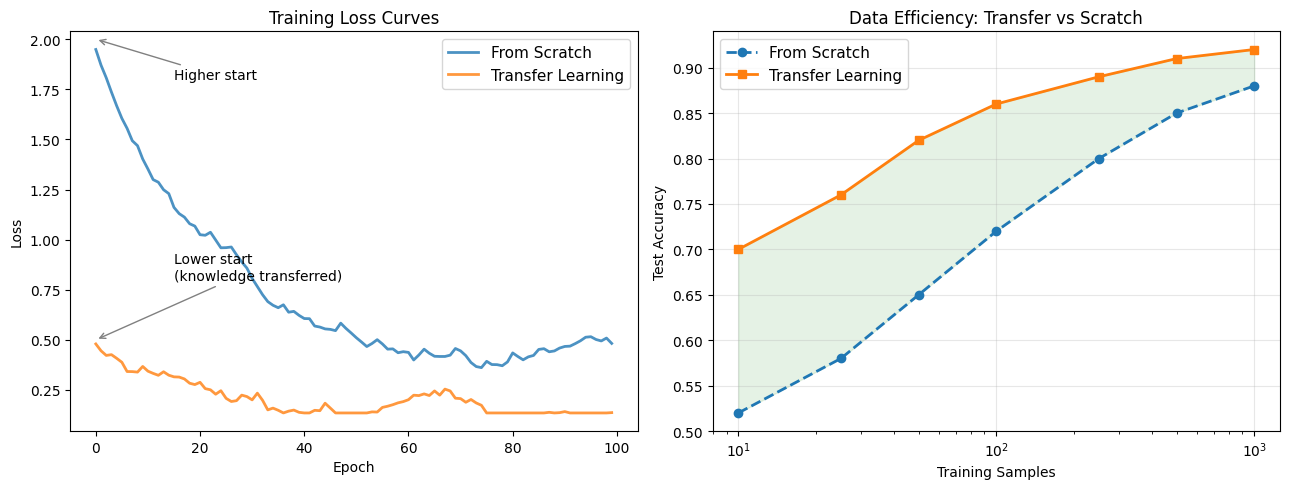

The shaded area represents the "transfer learning advantage"


In [7]:
# Simulate learning curves: transfer vs scratch
def simulate_learning_curve(n_epochs=100, transfer=False):
    """Simulate training loss curve."""
    if transfer:
        # Transfer: starts lower, converges faster
        initial_loss = 0.5
        convergence_rate = 0.08
        final_loss = 0.15
    else:
        # From scratch: starts higher, converges slower
        initial_loss = 2.0
        convergence_rate = 0.04
        final_loss = 0.25
    
    losses = []
    loss = initial_loss
    for epoch in range(n_epochs):
        loss = final_loss + (loss - final_loss) * (1 - convergence_rate)
        loss += np.random.randn() * 0.02  # noise
        losses.append(max(loss, final_loss * 0.9))
    return losses

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Loss curves
scratch_losses = simulate_learning_curve(transfer=False)
transfer_losses = simulate_learning_curve(transfer=True)

axes[0].plot(scratch_losses, label='From Scratch', linewidth=2, alpha=0.8)
axes[0].plot(transfer_losses, label='Transfer Learning', linewidth=2, alpha=0.8)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss Curves')
axes[0].legend(fontsize=11)
axes[0].annotate('Higher start', xy=(0, 2.0), xytext=(15, 1.8),
                arrowprops=dict(arrowstyle='->', color='gray'), fontsize=10)
axes[0].annotate('Lower start\n(knowledge transferred)', xy=(0, 0.5), xytext=(15, 0.8),
                arrowprops=dict(arrowstyle='->', color='gray'), fontsize=10)

# Accuracy vs data size
data_sizes = [10, 25, 50, 100, 250, 500, 1000]
scratch_acc = [0.52, 0.58, 0.65, 0.72, 0.80, 0.85, 0.88]
transfer_acc = [0.70, 0.76, 0.82, 0.86, 0.89, 0.91, 0.92]

axes[1].plot(data_sizes, scratch_acc, 'o--', label='From Scratch', linewidth=2)
axes[1].plot(data_sizes, transfer_acc, 's-', label='Transfer Learning', linewidth=2)
axes[1].set_xlabel('Training Samples'); axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('Data Efficiency: Transfer vs Scratch')
axes[1].set_xscale('log'); axes[1].legend(fontsize=11)
axes[1].fill_between(data_sizes, scratch_acc, transfer_acc, alpha=0.1, color='green')
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
print('The shaded area represents the "transfer learning advantage"')

## 6. Negative Transfer

Transfer learning can **hurt** when source and target domains are too different.
The pretrained features may be misleading rather than helpful.

In [8]:
# Demonstrate negative transfer with very different domains
np.random.seed(42)

# Source: features learned from text data (simulated)
W_text = np.random.randn(10, 5)

# Target: completely different domain (e.g., sensor data)
W_sensor = np.random.randn(10, 5) * 3  # very different transformation

X_target_sensor = np.random.randn(100, 10)
y_target_sensor = (X_target_sensor @ W_sensor[:, :1] > 0).astype(int).ravel()

X_tr, X_te, y_tr, y_te = train_test_split(X_target_sensor, y_target_sensor, test_size=0.3)

# Using text features (wrong domain!) for sensor task
X_tr_text_feat = np.tanh(X_tr @ W_text)
X_te_text_feat = np.tanh(X_te @ W_text)
m_wrong = LogisticRegression(max_iter=200).fit(X_tr_text_feat, y_tr)
acc_wrong = accuracy_score(y_te, m_wrong.predict(X_te_text_feat))

# Using raw features (no transfer)
m_raw = LogisticRegression(max_iter=200).fit(X_tr, y_tr)
acc_raw = accuracy_score(y_te, m_raw.predict(X_te))

# Using correct domain features
X_tr_correct = np.tanh(X_tr @ W_sensor)
X_te_correct = np.tanh(X_te @ W_sensor)
m_correct = LogisticRegression(max_iter=200).fit(X_tr_correct, y_tr)
acc_correct = accuracy_score(y_te, m_correct.predict(X_te_correct))

print(f'Wrong-domain transfer (text→sensor):  {acc_wrong:.3f}  ← NEGATIVE TRANSFER')
print(f'No transfer (raw features):            {acc_raw:.3f}')
print(f'Correct-domain transfer:               {acc_correct:.3f}')
print(f'\n→ Transferring from an unrelated domain made things WORSE!')

Wrong-domain transfer (text→sensor):  0.633  ← NEGATIVE TRANSFER
No transfer (raw features):            0.933
Correct-domain transfer:               1.000

→ Transferring from an unrelated domain made things WORSE!


## 7. Practical Guide: When & How to Transfer

| Scenario | Strategy | Example |
|----------|----------|--------|
| Small target, similar domain | Feature extraction | Medical images → X-ray diagnosis |
| Medium target, similar domain | Fine-tune last layers | ImageNet → flower classification |
| Large target, different domain | Fine-tune all layers | Text → code generation |
| Very different domain | Train from scratch | Images → tabular data |

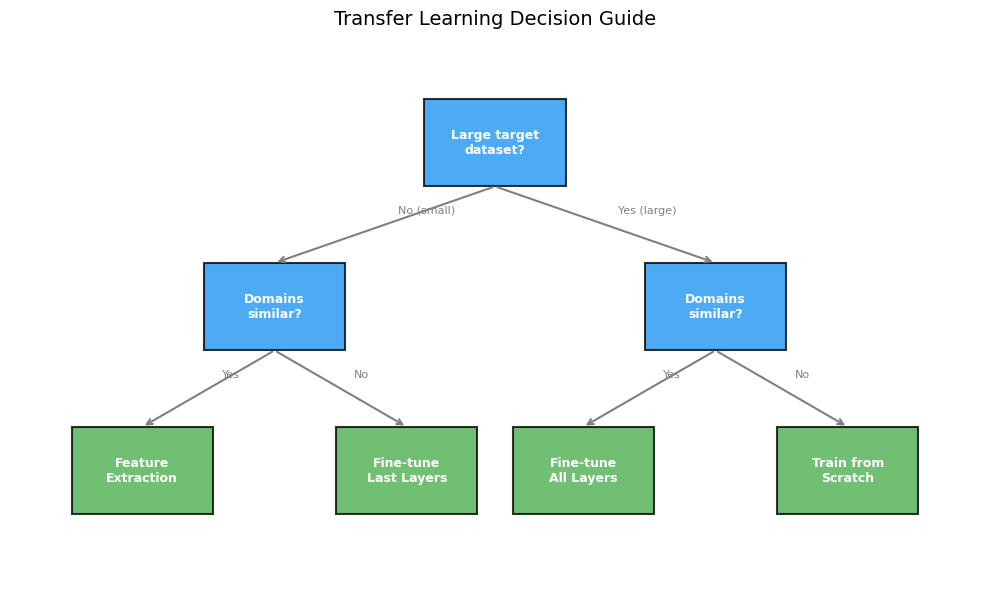

In [9]:
# Decision flowchart data
fig, ax = plt.subplots(figsize=(10, 6))

boxes = {
    'start': (5, 5.5, 'Large target\ndataset?'),
    'sim_yes': (2.5, 4, 'Domains\nsimilar?'),
    'sim_no': (7.5, 4, 'Domains\nsimilar?'),
    'fe': (1, 2.5, 'Feature\nExtraction'),
    'ft_partial': (4, 2.5, 'Fine-tune\nLast Layers'),
    'ft_full': (6, 2.5, 'Fine-tune\nAll Layers'),
    'scratch': (9, 2.5, 'Train from\nScratch'),
}

for key, (x, y, text) in boxes.items():
    color = '#4CAF50' if key in ['fe', 'ft_partial', 'ft_full', 'scratch'] else '#2196F3'
    ax.add_patch(plt.Rectangle((x-0.8, y-0.4), 1.6, 0.8, facecolor=color,
                               edgecolor='black', alpha=0.8, linewidth=1.5))
    ax.text(x, y, text, ha='center', va='center', fontsize=9, fontweight='bold', color='white')

# Arrows with labels
arrows = [
    (5, 5.1, 2.5, 4.4, 'No (small)'),
    (5, 5.1, 7.5, 4.4, 'Yes (large)'),
    (2.5, 3.6, 1, 2.9, 'Yes'), (2.5, 3.6, 4, 2.9, 'No'),
    (7.5, 3.6, 6, 2.9, 'Yes'), (7.5, 3.6, 9, 2.9, 'No'),
]
for x1, y1, x2, y2, label in arrows:
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
               arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
    ax.text((x1+x2)/2 + 0.15, (y1+y2)/2 + 0.1, label, fontsize=8, color='gray')

ax.set_xlim(-0.5, 10.5); ax.set_ylim(1.5, 6.5)
ax.set_title('Transfer Learning Decision Guide', fontsize=14)
ax.axis('off'); plt.tight_layout(); plt.show()

## 8. Interview Takeaways

**Key concepts to nail:**

- **Transfer learning** reuses features from a pretrained model on a new task
- **Feature extraction** freezes all pretrained layers; **fine-tuning** updates some/all
- Transfer works best when source and target domains are **related**
- **Domain adaptation** aligns feature distributions between source and target
- **Negative transfer**: unrelated source can hurt — always benchmark vs. scratch
- **Covariate shift**: input distributions differ; **concept drift**: relationship changes
- In NLP: pretrained LLMs (BERT, GPT) → fine-tune on downstream tasks
- In CV: ImageNet pretrained backbones → fine-tune for specific vision tasks
- **Learning rate strategy**: lower LR for pretrained layers, higher for new layers

---

<small><em>© 2026 AI Nirvana · More Info: https://medium.com/@snigam/a-simple-structured-way-to-prepare-for-ai-ml-interviews-68b2e5830195 · Disclaimer: Provided as is. No liability assumed.</em></small>